In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Admin\Desktop\PYTHON\customer_churn_list.csv')



In [3]:
df.head()

,Customer_ID,Age,Gender,Location,Tenure_Months,Subscription_Type,Monthly_Charges,Usage_Hours,Support_Tickets,Payment_Method,Number_of_Services,Churn
0,CUST100001,22,Female,Pune,3,Standard,62.06,16.1,1,Credit Card,2,No
1,CUST100002,59,Male,Hyderabad,44,Basic,26.64,8.1,1,UPI,4,No
2,CUST100003,52,Male,Hyderabad,13,Basic,24.69,9.2,3,Credit Card,4,No
3,CUST100004,41,Male,Chennai,43,Premium,102.29,39.8,4,Credit Card,2,No
4,CUST100005,40,Female,Hyderabad,34,Standard,61.71,20.2,2,UPI,1,No


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         5000 non-null   str    
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   str    
 3   Location            5000 non-null   str    
 4   Tenure_Months       5000 non-null   int64  
 5   Subscription_Type   5000 non-null   str    
 6   Monthly_Charges     5000 non-null   float64
 7   Usage_Hours         5000 non-null   float64
 8   Support_Tickets     5000 non-null   int64  
 9   Payment_Method      5000 non-null   str    
 10  Number_of_Services  5000 non-null   int64  
 11  Churn               5000 non-null   str    
dtypes: float64(2), int64(4), str(6)
memory usage: 662.7 KB


In [5]:
df.shape

(5000, 12)

In [6]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [7]:
df.describe()

,Age,Tenure_Months,Monthly_Charges,Usage_Hours,Support_Tickets,Number_of_Services
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,43.925200,30.712800,54.690438,18.47008,1.700800,2.973200
std,15.337061,17.287721,26.155364,8.81263,1.318798,1.406015
min,18.000000,1.000000,19.440000,1.00000,0.000000,1.000000
25%,31.000000,16.000000,30.047500,12.30000,1.000000,2.000000
50%,44.000000,31.000000,56.795000,18.50000,2.000000,3.000000
75%,57.000000,46.000000,62.402500,24.40000,2.000000,4.000000
max,70.000000,60.000000,109.670000,47.90000,9.000000,5.000000


In [8]:
df['Churn'].value_counts()

Churn
No     4791
Yes     209
Name: count, dtype: int64

In [9]:
churn_customers = 209
total_customers = 5000
churn_rate = churn_customers / total_customers * 100
churn_rate

4.18

In [10]:
df['Tenure_Group'] = pd.cut(
    df['Tenure_Months'],
    bins=[0, 12, 24, 36, 48, 60],
    labels=['1-12 months', '13-24 months', '25-36 months', '37-48 months', '49-60 months']
)

In [11]:
df['Tenure_Group'].value_counts()

Tenure_Group
37-48 months    1047
49-60 months     996
25-36 months     993
1-12 months      988
13-24 months     976
Name: count, dtype: int64

In [12]:
df[['Tenure_Group','Churn']].value_counts()

Tenure_Group  Churn
37-48 months  No       1025
49-60 months  No        969
25-36 months  No        952
1-12 months   No        924
13-24 months  No        921
1-12 months   Yes        64
13-24 months  Yes        55
25-36 months  Yes        41
49-60 months  Yes        27
37-48 months  Yes        22
Name: count, dtype: int64

In [13]:
churn_rate_by_tenure = df.groupby('Tenure_Group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

churn_rate_by_tenure

Tenure_Group
1-12 months     6.477733
13-24 months    5.635246
25-36 months    4.128902
37-48 months    2.101242
49-60 months    2.710843
Name: Churn, dtype: float64

In [14]:
df['Charge_Group'] = pd.cut(
    df['Monthly_Charges'],
    bins=[19, 39, 59, 79, 99, 110],
    labels=['19-39', '40-59', '60-79', '80-99', '100-110']
)

In [15]:
df['Charge_Group'].value_counts()

Charge_Group
19-39      2082
60-79       980
40-59       928
80-99       523
100-110     487
Name: count, dtype: int64

In [16]:
churn_rate_by_monthly_charges = df.groupby('Charge_Group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

churn_rate_by_monthly_charges

Charge_Group
19-39      5.283381
40-59      2.693966
60-79      3.877551
80-99      2.868069
100-110    4.312115
Name: Churn, dtype: float64

In [17]:
df['Support_Group'] = pd.cut(
    df['Support_Tickets'],
    bins=[-1,2,5,9],
    labels=['0-2 tickets', '3-5 tickets', '6-9 tickets']
)

In [18]:
df['Support_Group'].value_counts()

Support_Group
0-2 tickets    3803
3-5 tickets    1149
6-9 tickets      48
Name: count, dtype: int64

In [19]:
churn_rate_by_support_tickets = df.groupby('Support_Group')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

churn_rate_by_support_tickets

Support_Group
0-2 tickets    3.944255
3-5 tickets    4.960836
6-9 tickets    4.166667
Name: Churn, dtype: float64

In [20]:
df['Subscription_Type'].value_counts()

Subscription_Type
Basic       2082
Standard    1908
Premium     1010
Name: count, dtype: int64

In [21]:
df.groupby('Subscription_Type')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

Subscription_Type
Basic       5.283381
Premium     3.564356
Standard    3.301887
Name: Churn, dtype: float64

In [22]:
df['Payment_Method'].value_counts()

Payment_Method
Credit Card       1351
UPI               1245
Debit Card        1081
Bank Transfer      713
Digital Wallet     610
Name: count, dtype: int64

In [23]:
df.groupby('Payment_Method')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

Payment_Method
Bank Transfer     4.488079
Credit Card       4.811251
Debit Card        3.422757
Digital Wallet    3.934426
UPI               4.096386
Name: Churn, dtype: float64

In [24]:
df['Usage_Hours'].value_counts()

Usage_Hours
1.0     145
18.7     42
20.2     36
17.5     33
22.6     32
       ... 
42.9      1
40.8      1
42.7      1
41.4      1
43.2      1
Name: count, Length: 422, dtype: int64

In [25]:
df['Usage_Hours'].min()
df['Usage_Hours'].max()


np.float64(47.9)

In [26]:
df['Usage_Group'] = pd.cut(
    df['Usage_Hours'],
    bins=[0, 12, 24, 36, 48],
    labels=['Low Usage' , 'Moderate Usage', 'High Usage', 'Very high Usage']
)

In [27]:
df['Usage_Group'].value_counts()

Usage_Group
Moderate Usage     2488
Low Usage          1200
High Usage         1176
Very high Usage     136
Name: count, dtype: int64

In [28]:
churn_rate_by_usage_hours = df.groupby('Usage_Group')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

churn_rate_by_usage_hours

Usage_Group
Low Usage          6.166667
Moderate Usage     3.456592
High Usage         3.826531
Very high Usage    2.941176
Name: Churn, dtype: float64

In [29]:
df['Number_of_Services'].value_counts()

Number_of_Services
2    1046
3    1012
1     999
4     976
5     967
Name: count, dtype: int64

In [30]:
df.groupby('Number_of_Services')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

Number_of_Services
1    5.605606
2    4.684512
3    3.952569
4    3.586066
5    2.998966
Name: Churn, dtype: float64

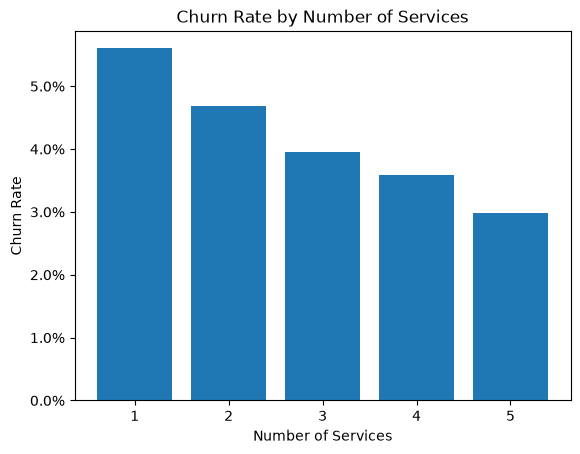

In [31]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

X = [1, 2, 3, 4, 5]
Y = [5.60, 4.68, 3.95, 3.58, 2.99]

plt.bar(X, Y)
plt.xlabel('Number of Services')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Number of Services')

plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))

plt.show()

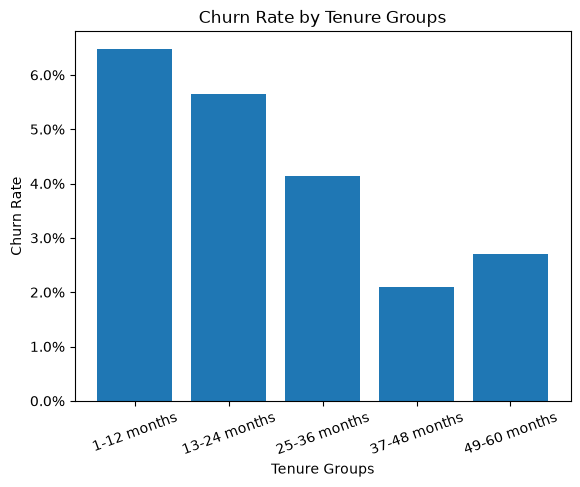

In [32]:

from matplotlib.ticker import PercentFormatter

X = ['1-12 months', '13-24 months', '25-36 months', '37-48 months', '49-60 months']
Y = [6.48, 5.64, 4.13, 2.10, 2.71]

plt.bar(X, Y)
plt.xlabel('Tenure Groups')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Tenure Groups')

plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
plt.xticks(rotation=20)

plt.show()

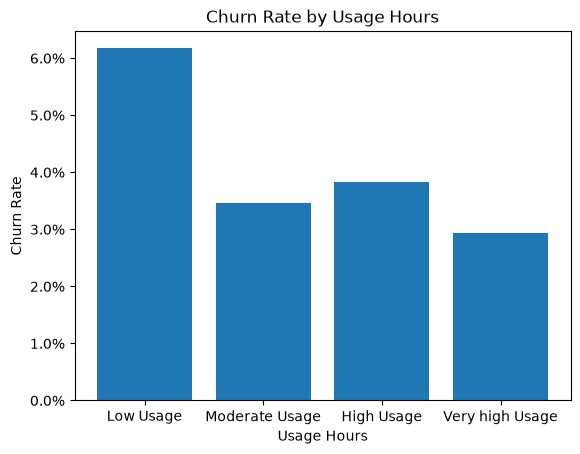

In [33]:

from matplotlib.ticker import PercentFormatter

X = ['Low Usage', 'Moderate Usage', 'High Usage', 'Very high Usage']
Y = [6.17, 3.46, 3.83, 2.94]

plt.bar(X, Y)
plt.xlabel('Usage Hours')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Usage Hours')

plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))

plt.show()

In [34]:
churn_rate_tenure_usage = df.groupby(
    ['Tenure_Group', 'Usage_Group']
)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()

churn_rate_tenure_usage.columns = ['Tenure_Group', 'Usage_Group', 'Churn_Rate']

churn_rate_tenure_usage

,Tenure_Group,Usage_Group,Churn_Rate
0,1-12 months,Low Usage,9.016393
1,1-12 months,Moderate Usage,5.882353
2,1-12 months,High Usage,5.357143
3,1-12 months,Very high Usage,3.703704
4,13-24 months,Low Usage,7.662835
5,13-24 months,Moderate Usage,5.000000
6,13-24 months,High Usage,4.651163
7,13-24 months,Very high Usage,5.000000
8,25-36 months,Low Usage,6.477733
9,25-36 months,Moderate Usage,2.719665


In [35]:
churn_rate_tenure_usage.loc[
    churn_rate_tenure_usage['Churn_Rate'].idxmax()
]

Tenure_Group    1-12 months
Usage_Group       Low Usage
Churn_Rate         9.016393
Name: 0, dtype: object

In [36]:
df[
    (df['Tenure_Group'] == '1-12 months') &
    (df['Usage_Group'] == 'Low Usage')
].shape[0]

244

In [37]:
segment_churn_rate = 9.016393
overall_churn_rate = 4.18

churn_ratio = segment_churn_rate / overall_churn_rate
churn_ratio

2.1570318181818187

In [38]:
id0 = churn_rate_tenure_usage['Churn_Rate'] == 0

churn_rate_tenure_usage[id0]

,Tenure_Group,Usage_Group,Churn_Rate
19,49-60 months,Very high Usage,0.0


In [39]:
df[
    (df['Tenure_Group'] == '49-60 months') &
    (df['Usage_Group'] == 'Very high Usage')
].shape[0]

33

In [40]:
df.groupby(['Tenure_Group', 'Number_of_Services']).size()

Tenure_Group  Number_of_Services
1-12 months   1                     188
              2                     200
              3                     192
              4                     208
              5                     200
13-24 months  1                     218
              2                     195
              3                     199
              4                     202
              5                     162
25-36 months  1                     192
              2                     209
              3                     192
              4                     200
              5                     200
37-48 months  1                     219
              2                     231
              3                     208
              4                     179
              5                     210
49-60 months  1                     182
              2                     211
              3                     221
              4                     187
       

In [41]:
churn_rate_tenure_services = df.groupby(
    ['Tenure_Group', 'Number_of_Services']
)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()

churn_rate_tenure_services.columns = [
    'Tenure_Group',
    'Number_of_Services',
    'Churn_Rate'
]

churn_rate_tenure_services

,Tenure_Group,Number_of_Services,Churn_Rate
0,1-12 months,1,11.170213
1,1-12 months,2,5.000000
2,1-12 months,3,9.375000
3,1-12 months,4,3.365385
4,1-12 months,5,4.000000
5,13-24 months,1,5.504587
6,13-24 months,2,10.256410
7,13-24 months,3,3.517588
8,13-24 months,4,3.960396
9,13-24 months,5,4.938272


In [42]:
churn_rate_tenure_services.loc[
    churn_rate_tenure_services['Churn_Rate'].idxmax()
]

Tenure_Group          1-12 months
Number_of_Services              1
Churn_Rate              11.170213
Name: 0, dtype: object

In [43]:
churn_rate_tenure_services.loc[
    churn_rate_tenure_services['Churn_Rate'].idxmin()
]

Tenure_Group          49-60 months
Number_of_Services               5
Churn_Rate                0.512821
Name: 24, dtype: object

In [45]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[17, 25, 35, 45, 55, 70],
    labels=['18-25', '26-35', '36-45', '46-55', '56-70']
)

In [47]:
df['Age_Group'].value_counts()

Age_Group
56-70    1451
26-35     967
36-45     954
46-55     868
18-25     760
Name: count, dtype: int64

In [48]:
churn_rate_by_age = df.groupby('Age_Group')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

churn_rate_by_age

Age_Group
18-25    4.078947
26-35    3.102378
36-45    4.716981
46-55    3.917051
56-70    4.755341
Name: Churn, dtype: float64

In [49]:
df['Gender'].unique()

<ArrowStringArray>
['Female', 'Male', 'Non-binary']
Length: 3, dtype: str

In [50]:
df.groupby('Gender')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

Gender
Female        4.302423
Male          4.082474
Non-binary    3.867403
Name: Churn, dtype: float64

In [52]:
df['Location'].unique()

<ArrowStringArray>
[     'Pune', 'Hyderabad',   'Chennai',    'Mumbai', 'Bengaluru',     'Delhi',
    'Nagpur',    'Nashik']
Length: 8, dtype: str

In [53]:
df.groupby('Location')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

Location
Bengaluru    5.073650
Chennai      3.030303
Delhi        5.528455
Hyderabad    2.880000
Mumbai       3.616352
Nagpur       4.870130
Nashik       3.204047
Pune         5.279503
Name: Churn, dtype: float64

In [58]:
df['Tenure_Months'].mean()

np.float64(30.7128)

In [62]:
df.groupby('Churn')['Tenure_Months'].mean()


Churn
No     30.992903
Yes    24.291866
Name: Tenure_Months, dtype: float64

In [64]:
df.groupby('Churn')['Monthly_Charges'].mean()


Churn
No     54.868019
Yes    50.619665
Name: Monthly_Charges, dtype: float64

In [66]:
df.groupby('Churn')['Usage_Hours'].mean()


Churn
No     18.569192
Yes    16.198086
Name: Usage_Hours, dtype: float64

In [67]:
df.groupby('Churn')['Support_Tickets'].mean()

Churn
No     1.694427
Yes    1.846890
Name: Support_Tickets, dtype: float64

In [69]:
df.groupby('Churn')['Number_of_Services'].mean()

Churn
No     2.986224
Yes    2.674641
Name: Number_of_Services, dtype: float64

In [70]:
df.groupby('Churn')['Age'].mean()

Churn
No     43.867042
Yes    45.258373
Name: Age, dtype: float64

In [73]:
df['Churn_Numeric'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [74]:
df['Churn_Numeric'].value_counts()

Churn_Numeric
0    4791
1     209
Name: count, dtype: int64

In [83]:
df[['Age', 'Tenure_Months', 'Monthly_Charges', 'Usage_Hours',
    'Support_Tickets', 'Number_of_Services', 'Churn_Numeric']].corr()['Churn_Numeric']

Age                   0.018157
Tenure_Months        -0.077583
Monthly_Charges      -0.032510
Usage_Hours          -0.053852
Support_Tickets       0.023139
Number_of_Services   -0.044355
Churn_Numeric         1.000000
Name: Churn_Numeric, dtype: float64

In [84]:
df.groupby('Subscription_Type')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

Subscription_Type
Basic       5.283381
Premium     3.564356
Standard    3.301887
Name: Churn, dtype: float64

In [85]:
df.groupby('Payment_Method')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

Payment_Method
Bank Transfer     4.488079
Credit Card       4.811251
Debit Card        3.422757
Digital Wallet    3.934426
UPI               4.096386
Name: Churn, dtype: float64

In [87]:
df.groupby('Location')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

Location
Bengaluru    5.073650
Chennai      3.030303
Delhi        5.528455
Hyderabad    2.880000
Mumbai       3.616352
Nagpur       4.870130
Nashik       3.204047
Pune         5.279503
Name: Churn, dtype: float64

In [88]:
churn_rate_tenure_usage.sort_values('Churn_Rate', ascending=False)

,Tenure_Group,Usage_Group,Churn_Rate
0,1-12 months,Low Usage,9.016393
4,13-24 months,Low Usage,7.662835
8,25-36 months,Low Usage,6.477733
1,1-12 months,Moderate Usage,5.882353
2,1-12 months,High Usage,5.357143
7,13-24 months,Very high Usage,5.000000
5,13-24 months,Moderate Usage,5.000000
6,13-24 months,High Usage,4.651163
10,25-36 months,High Usage,4.508197
11,25-36 months,Very high Usage,4.166667


In [89]:
churn_rate_tenure_services.sort_values('Churn_Rate', ascending=False)

,Tenure_Group,Number_of_Services,Churn_Rate
0,1-12 months,1,11.170213
6,13-24 months,2,10.256410
2,1-12 months,3,9.375000
13,25-36 months,4,6.000000
5,13-24 months,1,5.504587
10,25-36 months,1,5.208333
1,1-12 months,2,5.000000
20,49-60 months,1,4.945055
9,13-24 months,5,4.938272
4,1-12 months,5,4.000000


In [90]:
df[df['Churn'] == 'Yes']['Monthly_Charges'].sum()

np.float64(10579.51)

In [91]:
df[df['Churn'] == 'Yes']['Monthly_Charges'].mean()

np.float64(50.619665071770335)

In [92]:
id="7m4kx"
df[df['Churn'] == 'Yes'].groupby('Subscription_Type')['Monthly_Charges'].sum()

Subscription_Type
Basic       3239.25
Premium     3578.78
Standard    3761.48
Name: Monthly_Charges, dtype: float64

In [93]:
df[df['Churn'] == 'Yes']['Subscription_Type'].value_counts()

Subscription_Type
Basic       110
Standard     63
Premium      36
Name: count, dtype: int64

In [94]:
df[df['Churn'] == 'Yes']['Location'].value_counts()

Location
Pune         34
Delhi        34
Bengaluru    31
Nagpur       30
Mumbai       23
Chennai      20
Nashik       19
Hyderabad    18
Name: count, dtype: int64

In [95]:
df[df['Churn'] == 'Yes'].groupby('Location')['Monthly_Charges'].sum().sort_values(ascending=False)

Location
Pune         1866.69
Bengaluru    1718.85
Delhi        1679.13
Nagpur       1270.40
Chennai      1121.87
Mumbai       1074.82
Nashik       1060.20
Hyderabad     787.55
Name: Monthly_Charges, dtype: float64

In [96]:
churn_rate_3factor = df.groupby(
    ['Tenure_Group', 'Usage_Group', 'Number_of_Services']
)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()

churn_rate_3factor.columns = [
    'Tenure_Group',
    'Usage_Group',
    'Number_of_Services',
    'Churn_Rate'
]

churn_rate_3factor.sort_values('Churn_Rate', ascending=False)

,Tenure_Group,Usage_Group,Number_of_Services,Churn_Rate
38,13-24 months,Very high Usage,4,25.000000
21,13-24 months,Low Usage,2,17.647059
55,25-36 months,Very high Usage,1,16.666667
0,1-12 months,Low Usage,1,15.555556
15,1-12 months,Very high Usage,1,12.500000
...,...,...,...,...
95,49-60 months,Very high Usage,1,0.000000
96,49-60 months,Very high Usage,2,0.000000
97,49-60 months,Very high Usage,3,0.000000
98,49-60 months,Very high Usage,4,0.000000


In [97]:
segment_summary = df.groupby(
    ['Tenure_Group', 'Usage_Group', 'Number_of_Services']
).agg(
    Customer_Count=('Churn', 'count'),
    Churned_Customers=('Churn', lambda x: (x == 'Yes').sum())
).reset_index()

segment_summary['Churn_Rate'] = (
    segment_summary['Churned_Customers']
    / segment_summary['Customer_Count']
) * 100

segment_summary.sort_values('Churn_Rate', ascending=False)

,Tenure_Group,Usage_Group,Number_of_Services,Customer_Count,Churned_Customers,Churn_Rate
38,13-24 months,Very high Usage,4,4,1,25.000000
21,13-24 months,Low Usage,2,51,9,17.647059
55,25-36 months,Very high Usage,1,6,1,16.666667
0,1-12 months,Low Usage,1,45,7,15.555556
15,1-12 months,Very high Usage,1,8,1,12.500000
...,...,...,...,...,...,...
95,49-60 months,Very high Usage,1,6,0,0.000000
96,49-60 months,Very high Usage,2,8,0,0.000000
97,49-60 months,Very high Usage,3,7,0,0.000000
98,49-60 months,Very high Usage,4,4,0,0.000000


In [98]:
high_risk = df[
    (df['Tenure_Months'] <= 24) &
    (df['Usage_Group'] == 'Low Usage') &
    (df['Number_of_Services'] <= 2)
]

high_risk_churn_rate = (high_risk['Churn'] == 'Yes').mean() * 100

high_risk.shape[0], high_risk_churn_rate

(196, np.float64(10.714285714285714))